In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcY2pmb29cRG9jdW1lbnRzXE1hdGg0MDI1XENPTUFQIFByZXNlbnRhdGlvblxDT01BUC1NQVRILTQ5OTg='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Users\\cjfoo\\miniforge3\\envs\\math4025\\Lib\\importlib\\_bootstrap.py": 1770132740.0, "C:\\Users\\cjfoo\\miniforge3\\envs\\math4025\\Lib\\importlib\\_bootstrap_external.py": 1770132740.0, "C:\\Users\\cjfoo\\miniforge3\\envs\\math4025\\Lib\\zipimport.py": 1770132740.0, "C:\\Users\\cjfoo\\miniforge3\\envs\\math4025\\Lib\\codecs.py": 1770132740.0, "C:\\Users\\cjfoo\\miniforge3\\envs\\math4025\\Lib\\encodings\\aliases.py": 1770132740.0, "C:\\Users\\cjfoo\\miniforge3\\envs\\math4025\\Lib\\encodings\\_win_cp_codecs.py": 1770132740.0, "C:\\Users\\cjfoo\\miniforge3\\envs\\math4025\\Lib\\encodings\\__init__.py": 1770132740.0, "C:\\Users\\cjfoo\\miniforge3\\envs\\math4025\\Lib\\encodings\\utf_8.py": 1770132740.0, "C:\\Users\\cjfoo\\miniforge3\\envs\\math4025\\Lib\\encodings\\cp1252.py": 1770132740.0, "C:\\Users\\cjfoo\\miniforge3\\envs\\math4025\\Lib\\abc.py": 1770132740.0, "C:\\Users\\cjfoo\\miniforge3\\envs\\math4025\\Lib\\stat.py": 1770132740.0, "C:\\Users\\cjfoo\\miniforge3\\envs\\ma

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, KFold, cross_validate
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from plotnine import *

In [3]:
# To get just the Medal Counts description part:
medal_desc = pd.read_csv('2025_Problem_C_Data/data_dictionary.csv', skiprows=1, nrows=7, encoding = 'latin1')

# To get the Hosts description:
# You'd count the rows from the top to where "summerOly_hosts.csv" starts
hosts_desc = pd.read_csv('2025_Problem_C_Data/data_dictionary.csv', skiprows=12, nrows=3, encoding = 'latin1')
athletes = pd.read_csv("2025_Problem_C_Data/summerOly_athletes.csv")
hosts = pd.read_csv("2025_Problem_C_Data/summerOly_hosts.csv")
medal_counts = pd.read_csv("2025_Problem_C_Data/summerOly_medal_counts.csv")
# 1. Use encoding='latin1' or 'cp1252' to handle the '' characters
# 2. Use nrows to stop reading before the "Data set of current..." paragraph begins
df_programs = pd.read_csv('2025_Problem_C_Data/summerOly_programs.csv', 
    encoding='latin1', 
    nrows=75  # Adjust this number to the last row of actual data
    )

In [4]:
# 1. Load Data & Create Base History (Assuming data is already read in)
history = medal_counts.merge(hosts, on="Year", how="left")
history['is_Host'] = (history['NOC'] == history['Host']).astype(int)

# 2. Extract Athlete Demographics (Male, Female, and Total Athletes)
# Unstack the 'Sex' column to get separate columns for 'M' and 'F'
sex_counts = athletes.groupby(['Year', 'Team', 'Sex']).size().unstack(fill_value=0).reset_index()

# Handle potential missing columns if data is oddly shaped
if 'M' not in sex_counts.columns: sex_counts['M'] = 0
if 'F' not in sex_counts.columns: sex_counts['F'] = 0

sex_counts = sex_counts.rename(columns={'M': 'Male_Athletes', 'F': 'Female_Athletes'})
sex_counts['Total_Athletes'] = sex_counts['Male_Athletes'] + sex_counts['Female_Athletes']

# BONUS FEATURE: Sport Breadth (How many unique sports they competed in)
sport_breadth = athletes.groupby(['Year', 'Team'])['Sport'].nunique().reset_index(name='Unique_Sports')

# Merge demographics and sports breadth together
athlete_features = sex_counts.merge(sport_breadth, on=['Year', 'Team'], how='left')

# 3. Merge onto Final Training Data
final_training_data = history.merge(athlete_features, left_on=['Year', 'NOC'], right_on=['Year', 'Team'], how='left')
final_training_data = final_training_data.drop(columns=['Team', 'Host'])

# Fill NaNs for countries that won medals but might have no listed athletes
final_training_data[['Total_Athletes', 'Male_Athletes', 'Female_Athletes', 'Unique_Sports']] = \
    final_training_data[['Total_Athletes', 'Male_Athletes', 'Female_Athletes', 'Unique_Sports']].fillna(0)

# 4. Calculate Current Efficiency (Total Medals / Total Athletes)
# We use np.where to prevent division by zero errors
final_training_data['Current_Efficiency'] = np.where(
    final_training_data['Total_Athletes'] > 0,
    final_training_data['Total'] / final_training_data['Total_Athletes'],
    0
)

# 5. Feature Engineering: Create Lagged and Cumulative Variables
# VERY IMPORTANT: Sort by NOC then Year so shifts occur chronologically per country
final_training_data = final_training_data.sort_values(by=['NOC', 'Year'])

# The 1, 2, and 3 Olympic Lags for Efficiency
final_training_data['Lag_1_Efficiency'] = final_training_data.groupby('NOC')['Current_Efficiency'].shift(1)
final_training_data['Lag_2_Efficiency'] = final_training_data.groupby('NOC')['Current_Efficiency'].shift(2)
final_training_data['Lag_3_Efficiency'] = final_training_data.groupby('NOC')['Current_Efficiency'].shift(3)

# Total Historical Efficiency (The mean of all previous years)
# .expanding().mean() calculates the cumulative average, and .shift(1) prevents it from including the current year
final_training_data['Total_Historical_Efficiency'] = final_training_data.groupby('NOC')['Current_Efficiency'].transform(lambda x: x.expanding().mean().shift(1))

# BONUS FEATURE: Lag 1 Total Medals (Raw output memory)
final_training_data['Lag_1_Total_Medals'] = final_training_data.groupby('NOC')['Total'].shift(1)
final_training_data['Lag_2_Total_Medals'] = final_training_data.groupby('NOC')['Total'].shift(2)
final_training_data['Lag_3_Total_Medals'] = final_training_data.groupby('NOC')['Total'].shift(3)

# 6. Final Cleanup
# Fill NaNs generated by shifts (which occur when a country appears for the 1st, 2nd, or 3rd time)
# Final Cleanup
cols_to_fill = [
    'Lag_1_Efficiency', 'Lag_2_Efficiency', 'Lag_3_Efficiency', 
    'Total_Historical_Efficiency', 
    'Lag_1_Total_Medals', 'Lag_2_Total_Medals', 'Lag_3_Total_Medals'
]
final_training_data[cols_to_fill] = final_training_data[cols_to_fill].fillna(0)

# Drop the leaky Current_Efficiency so the model doesn't cheat
final_training_data = final_training_data.drop(columns=['Current_Efficiency'])
final_training_data.head()

,Rank,NOC,Gold,Silver,Bronze,Total,Year,is_Host,Female_Athletes,Male_Athletes,Total_Athletes,Unique_Sports,Lag_1_Efficiency,Lag_2_Efficiency,Lag_3_Efficiency,Total_Historical_Efficiency,Lag_1_Total_Medals,Lag_2_Total_Medals,Lag_3_Total_Medals
1073,82,Afghanistan,0,0,1,1,2008,0,1.0,3.0,4.0,2.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
1157,79,Afghanistan,0,0,1,1,2012,0,1.0,5.0,6.0,4.0,0.250000,0.0,0.0,0.250000,1.0,0.0,0.0
1423,80,Albania,0,0,2,2,2024,0,4.0,5.0,9.0,4.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
637,42,Algeria,0,0,2,2,1984,0,0.0,33.0,33.0,4.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
728,34,Algeria,1,0,1,2,1992,0,2.0,34.0,36.0,7.0,0.060606,0.0,0.0,0.060606,2.0,0.0,0.0


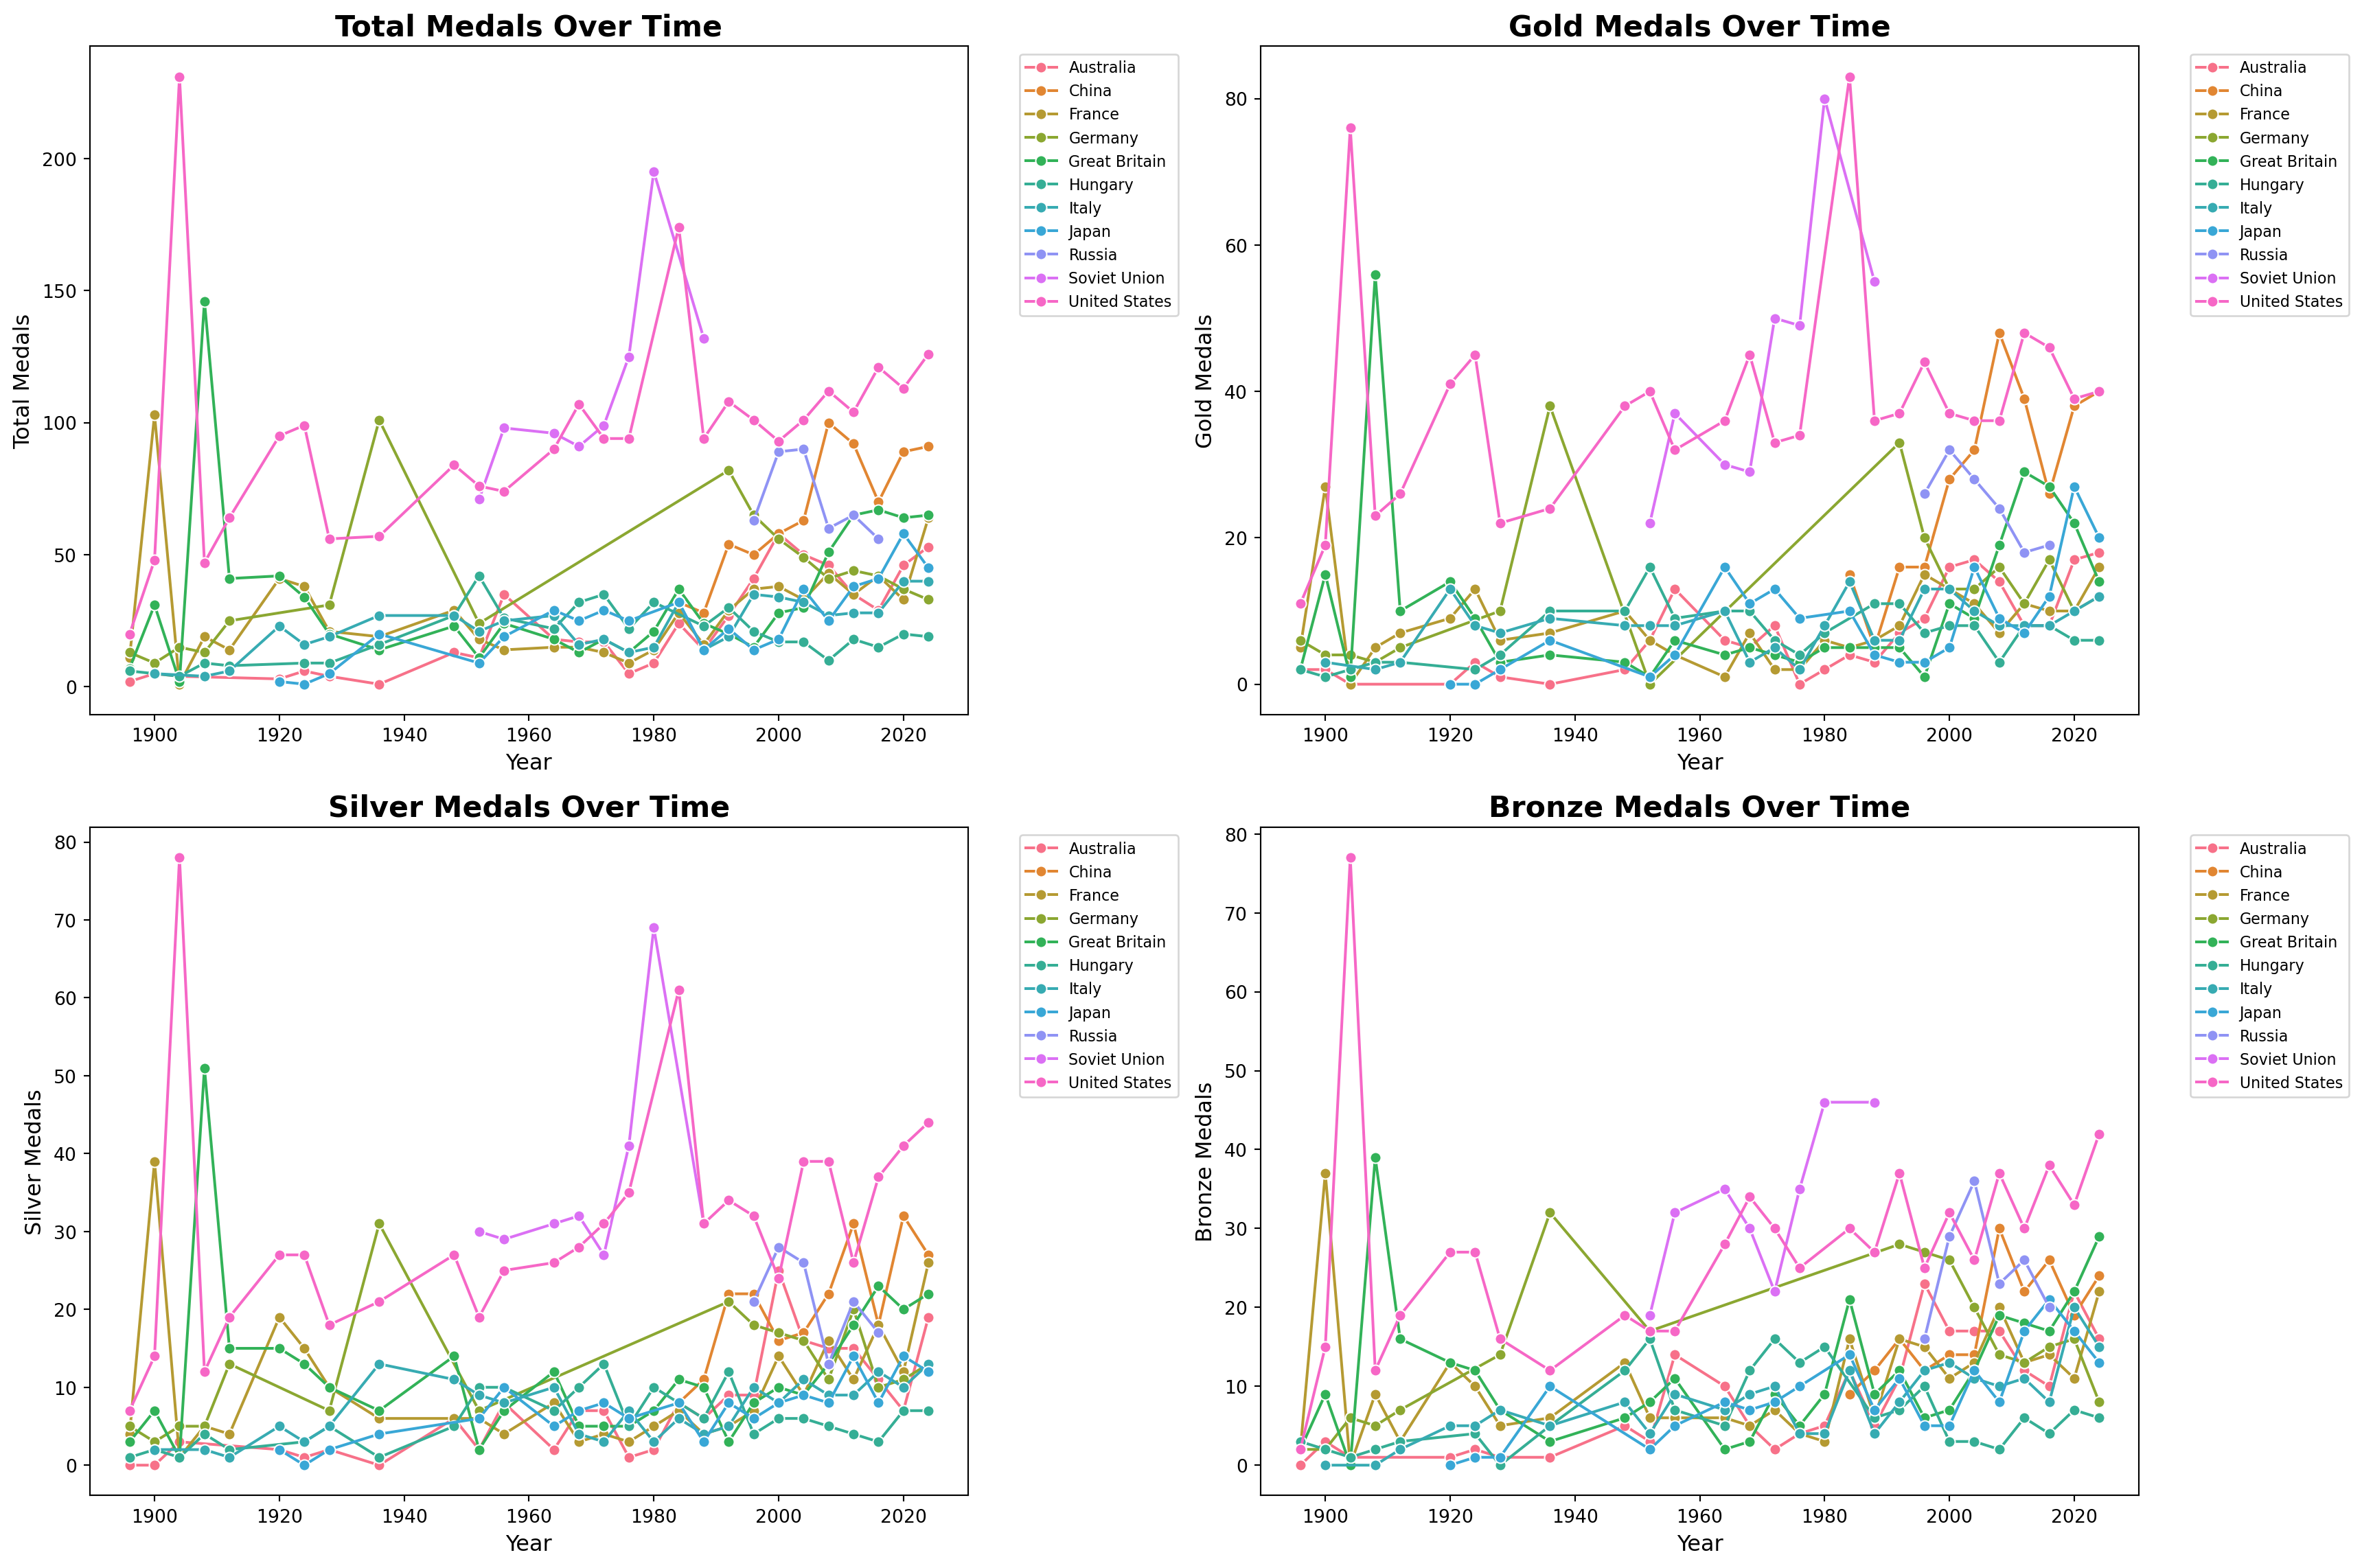

In [5]:
# Identify the Top 10 countries by all-time Total medals
# We use .tolist() so we can easily append another country to it
top_nocs = final_training_data.groupby('NOC')['Total'].sum().nlargest(10).index.tolist()

# Add Russia ('RUS') to the list making it 11 countries 
# (The if-statement ensures we don't add it twice if it naturally made the Top 10)
russia_code = 'Russia' 
if russia_code not in top_nocs:
    top_nocs.append(russia_code)

# Filter the dataframe to just these top countries + Russia
plot_data = final_training_data[final_training_data['NOC'].isin(top_nocs)]

# Set up a 2x2 grid for the 4 graphs
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

# Define the metrics and their respective graph titles
metrics = ['Total', 'Gold', 'Silver', 'Bronze']
titles = ['Total Medals Over Time', 'Gold Medals Over Time', 
          'Silver Medals Over Time', 'Bronze Medals Over Time']

# Loop through and create each plot
for i, metric in enumerate(metrics):
    sns.lineplot(
        data=plot_data, 
        x='Year', 
        y=metric, 
        hue='NOC', 
        marker='o',
        ax=axes[i]
    )
    
    axes[i].set_title(titles[i], fontsize=16, fontweight='bold')
    axes[i].set_xlabel('Year', fontsize=12)
    axes[i].set_ylabel(f'{metric} Medals', fontsize=12)
    
    # Move the legend outside of the plot area so it doesn't cover the lines
    axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()

In [6]:
features = ['Total_Athletes', 'Total_Historical_Efficiency', 'is_Host', 'Male_Athletes', 'Female_Athletes', 'Unique_Sports', 'Lag_1_Efficiency', 'Lag_2_Efficiency', 'Lag_3_Efficiency', 'Lag_1_Total_Medals', 'Lag_2_Total_Medals', 'Lag_3_Total_Medals']
X = final_training_data[features]

# 2. Your target is now a DataFrame with TWO columns
targets = ['Total', 'Gold']
y = final_training_data[targets]

X_train, X_test, y_train_multi, y_test_multi = train_test_split(X, y, train_size = .7, random_state = 4025)
num = [
    'Total_Athletes', 
    'Total_Historical_Efficiency', 
    'Male_Athletes', 
    'Female_Athletes', 
    'Unique_Sports', 
    'Lag_1_Efficiency', 
    'Lag_2_Efficiency', 
    'Lag_3_Efficiency', 
    'Lag_1_Total_Medals', 
    'Lag_2_Total_Medals', 
    'Lag_3_Total_Medals'
]
cat = [
    'is_Host'
]
numeric_transformer = Pipeline(steps=[
    # Fills any blank numeric values with the median of that column
    ('imputer', SimpleImputer(strategy='median')), 
    # Standardizes numbers to have a mean of 0 and variance of 1
    ('scaler', StandardScaler()) 
])
categorical_transformer = Pipeline(steps=[
    # Fills any blank categorical values with the most common category
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # Ensures categories are properly formatted for regression mathematics
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num),
    ('cat', categorical_transformer, cat)
])

In [7]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestRegressor())
])

param_grid_rf = {
    'rf__max_features': [1, 2, 3],
    'rf__n_estimators' : [50,100,200],
    'rf__max_depth' : [None, 5,10,15]
}
rf_cv = KFold(n_splits = 5, shuffle = True, random_state= 4025)

rf_grid = GridSearchCV(
    estimator = rf_pipeline,
    param_grid= param_grid_rf,
    cv = rf_cv,
    scoring='r2',
    return_train_score=True,
    n_jobs=-1
)
rf_grid.fit(X_train, y_train_multi)

# 6. Make Predictions and Evaluate
best_rf = rf_grid.best_estimator_
predictions = best_rf.predict(X_test)

predicted_total = predictions[:, 0]
predicted_gold = predictions[:, 1]

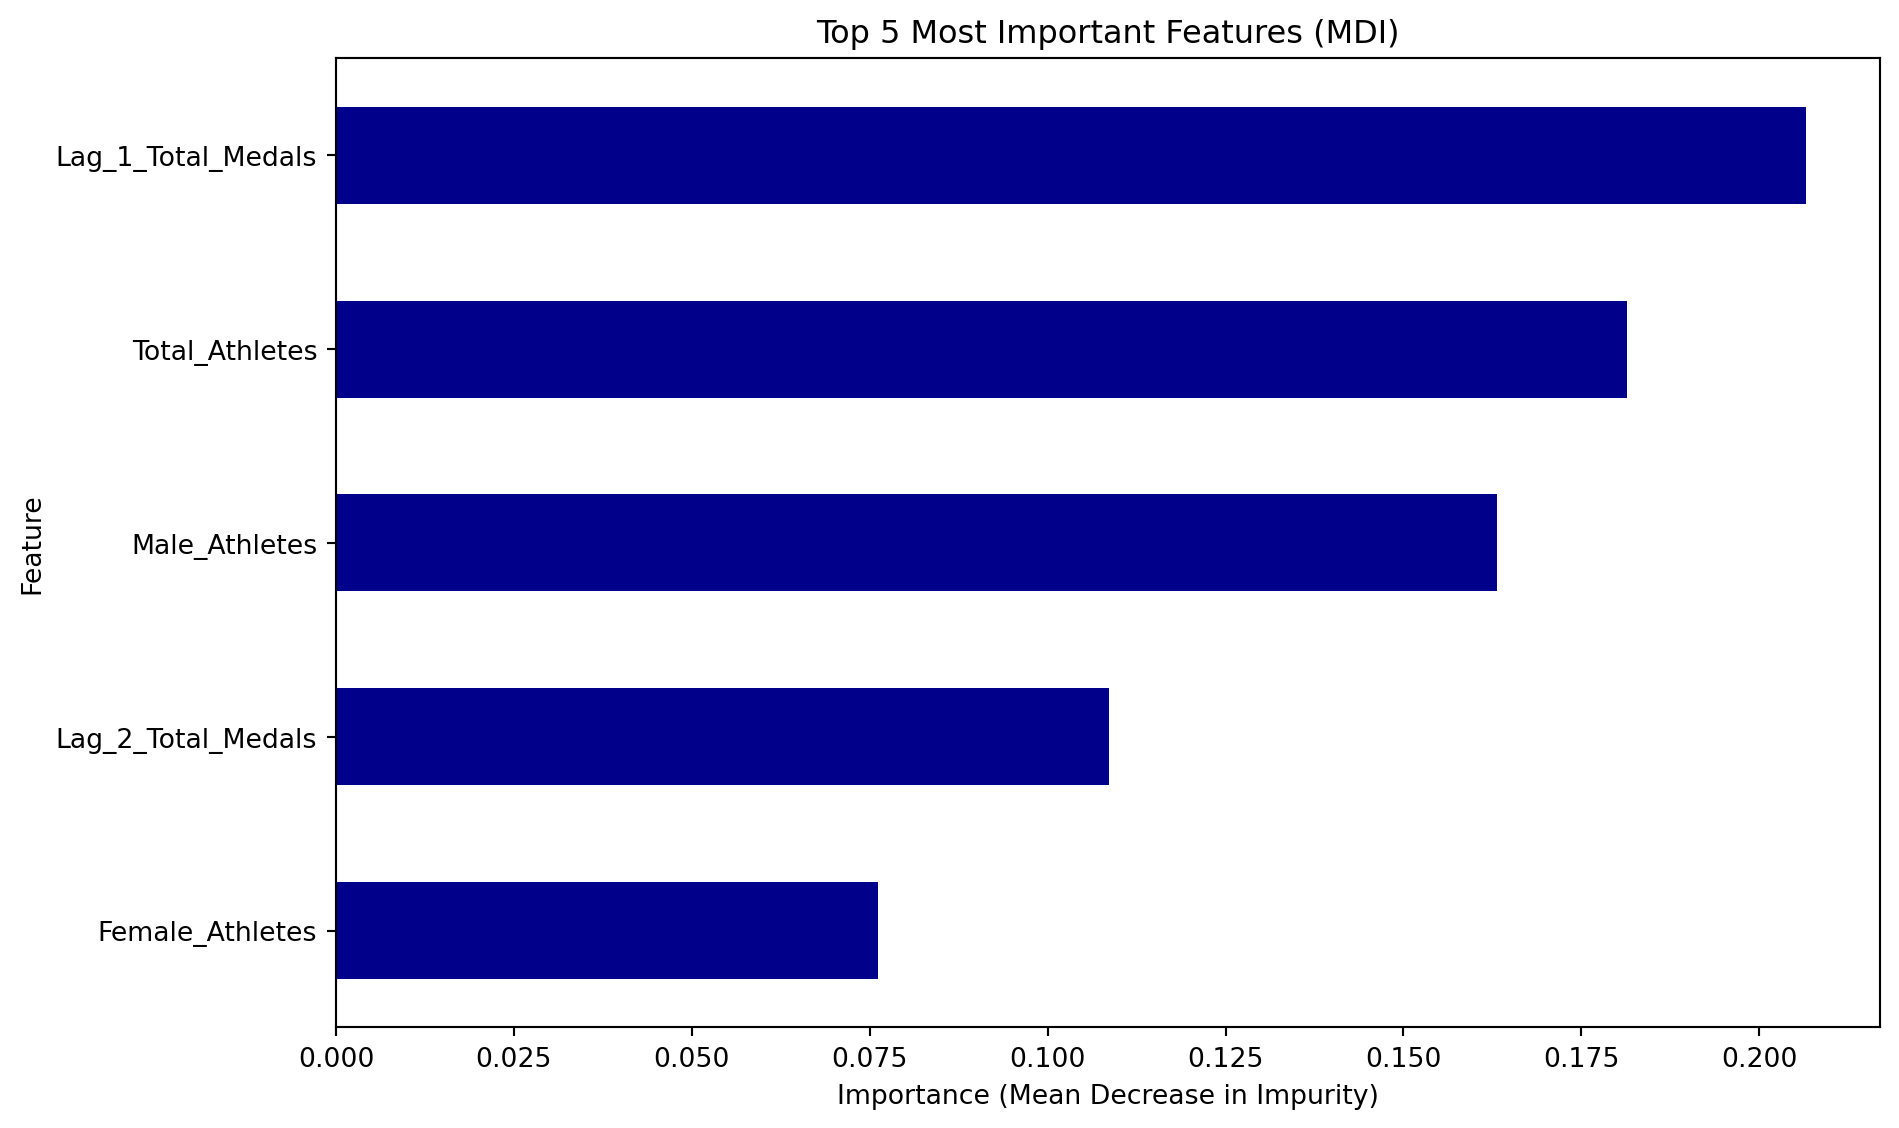

In [8]:
# 1. Extract the specific pieces from your best pipeline
# best_rf is your Pipeline object. We need the preprocessor and the actual Random Forest model.
preprocessor = best_rf.named_steps['preprocessor']
rf_model = best_rf.named_steps['rf']

# 2. Get the Feature Names out of the Preprocessor
# The preprocessor creates an array of names, but they often have prefixes like 'num__' or 'cat__'
raw_feature_names = preprocessor.get_feature_names_out()
clean_feature_names = [name.split('__')[-1] for name in raw_feature_names]

# Extract the feature importances from the model
importances = rf_model.feature_importances_

# Bind them to our clean feature names and sort them
importance_series = pd.Series(importances, index=clean_feature_names)
top_5_importances = importance_series.sort_values(ascending=False).head(5)

# Plot the bar chart
plt.figure(figsize=(10, 6))
# We sort ascending just for plotting so the biggest bar is on top
top_5_importances.sort_values(ascending=True).plot(kind='barh', color='darkblue')
plt.title('Top 5 Most Important Features (MDI)')
plt.xlabel('Importance (Mean Decrease in Impurity)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [9]:
# 1. Isolate the 2024 data - this is our "launch pad" for 2028
data_2024 = final_training_data[final_training_data['Year'] == 2024].copy()

# Create the base 2028 DataFrame
data_2028 = pd.DataFrame()
data_2028['NOC'] = data_2024['NOC'].values
data_2028['Year'] = 2028

# 2. USA gets the Host advantage
data_2028['is_Host'] = (data_2028['NOC'] == 'USA').astype(int)

# 3. Carry over the Demographic & Sport Data (Using 2024 as the proxy for 2028)
data_2028['Total_Athletes'] = data_2024['Total_Athletes'].values
data_2028['Male_Athletes'] = data_2024['Male_Athletes'].values
data_2028['Female_Athletes'] = data_2024['Female_Athletes'].values
data_2028['Unique_Sports'] = data_2024['Unique_Sports'].values

# 4. Shift the Medal Lags Forward
# 2028's Lag 1 is the ACTUAL medals won in 2024
data_2028['Lag_1_Total_Medals'] = data_2024['Total'].values
# 2028's Lag 2 is 2024's Lag 1 (which was 2020), and so on
data_2028['Lag_2_Total_Medals'] = data_2024['Lag_1_Total_Medals'].values
data_2028['Lag_3_Total_Medals'] = data_2024['Lag_2_Total_Medals'].values

# 5. Shift the Efficiency Lags Forward
# Calculate 2024's actual efficiency to use as 2028's Lag 1
actual_2024_efficiency = np.where(
    data_2024['Total_Athletes'] > 0, 
    data_2024['Total'] / data_2024['Total_Athletes'], 
    0
)
data_2028['Lag_1_Efficiency'] = actual_2024_efficiency
data_2028['Lag_2_Efficiency'] = data_2024['Lag_1_Efficiency'].values
data_2028['Lag_3_Efficiency'] = data_2024['Lag_2_Efficiency'].values

# Carry over the cumulative historical efficiency
data_2028['Total_Historical_Efficiency'] = data_2024['Total_Historical_Efficiency'].values

# 6. Ensure the features match EXACTLY the order the model was trained on
features = [
    'Total_Athletes', 'Total_Historical_Efficiency', 'is_Host', 
    'Male_Athletes', 'Female_Athletes', 'Unique_Sports', 
    'Lag_1_Efficiency', 'Lag_2_Efficiency', 'Lag_3_Efficiency', 
    'Lag_1_Total_Medals', 'Lag_2_Total_Medals', 'Lag_3_Total_Medals'
]
X_2028 = data_2028[features]

# 7. Make Predictions using your Best Random Forest Model!
# Note: best_rf is already fitted from your GridSearchCV step
predictions_2028 = best_rf.predict(X_2028)

# Extract Total and Gold, and round them to whole numbers
data_2028['Predicted_Total'] = np.round(predictions_2028[:, 0]).astype(int)
data_2028['Predicted_Gold'] = np.round(predictions_2028[:, 1]).astype(int)

# Random Forests rarely predict negative numbers, but clipping is a good safety net
data_2028['Predicted_Total'] = data_2028['Predicted_Total'].clip(lower=0)
data_2028['Predicted_Gold'] = data_2028['Predicted_Gold'].clip(lower=0)

# Sort by Most Gold Medals (Standard Olympic Ranking), then Most Total Medals
leaderboard_2028 = data_2028.sort_values(by=['Predicted_Gold', 'Predicted_Total'], ascending=[False, False])

# Print the Results!
print("\n" + "="*50)
print("🇺🇸 OFFICIAL 2028 LOS ANGELES MEDAL PROJECTIONS (RANDOM FOREST) 🇺🇸")
print("="*50)
print(leaderboard_2028[['NOC', 'Predicted_Gold', 'Predicted_Total']].head(20).to_string(index=False))


🇺🇸 OFFICIAL 2028 LOS ANGELES MEDAL PROJECTIONS (RANDOM FOREST) 🇺🇸
          NOC  Predicted_Gold  Predicted_Total
United States              44              122
        China              36               90
       France              26               71
Great Britain              24               70
    Australia              20               55
        Japan              14               45
      Germany              14               41
        Italy              13               40
  Netherlands              12               39
       Canada               9               32
  New Zealand               8               20
      Hungary               7               19
        Spain               6               21
  South Korea               6               17
       Brazil               4               20
  Switzerland               4               12
      Ukraine               3               13
       Poland               3               12
      Belgium               3           

C:\Users\cjfoo\AppData\Local\Temp\ipykernel_9408\2476064469.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

C:\Users\cjfoo\AppData\Local\Temp\ipykernel_9408\2476064469.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



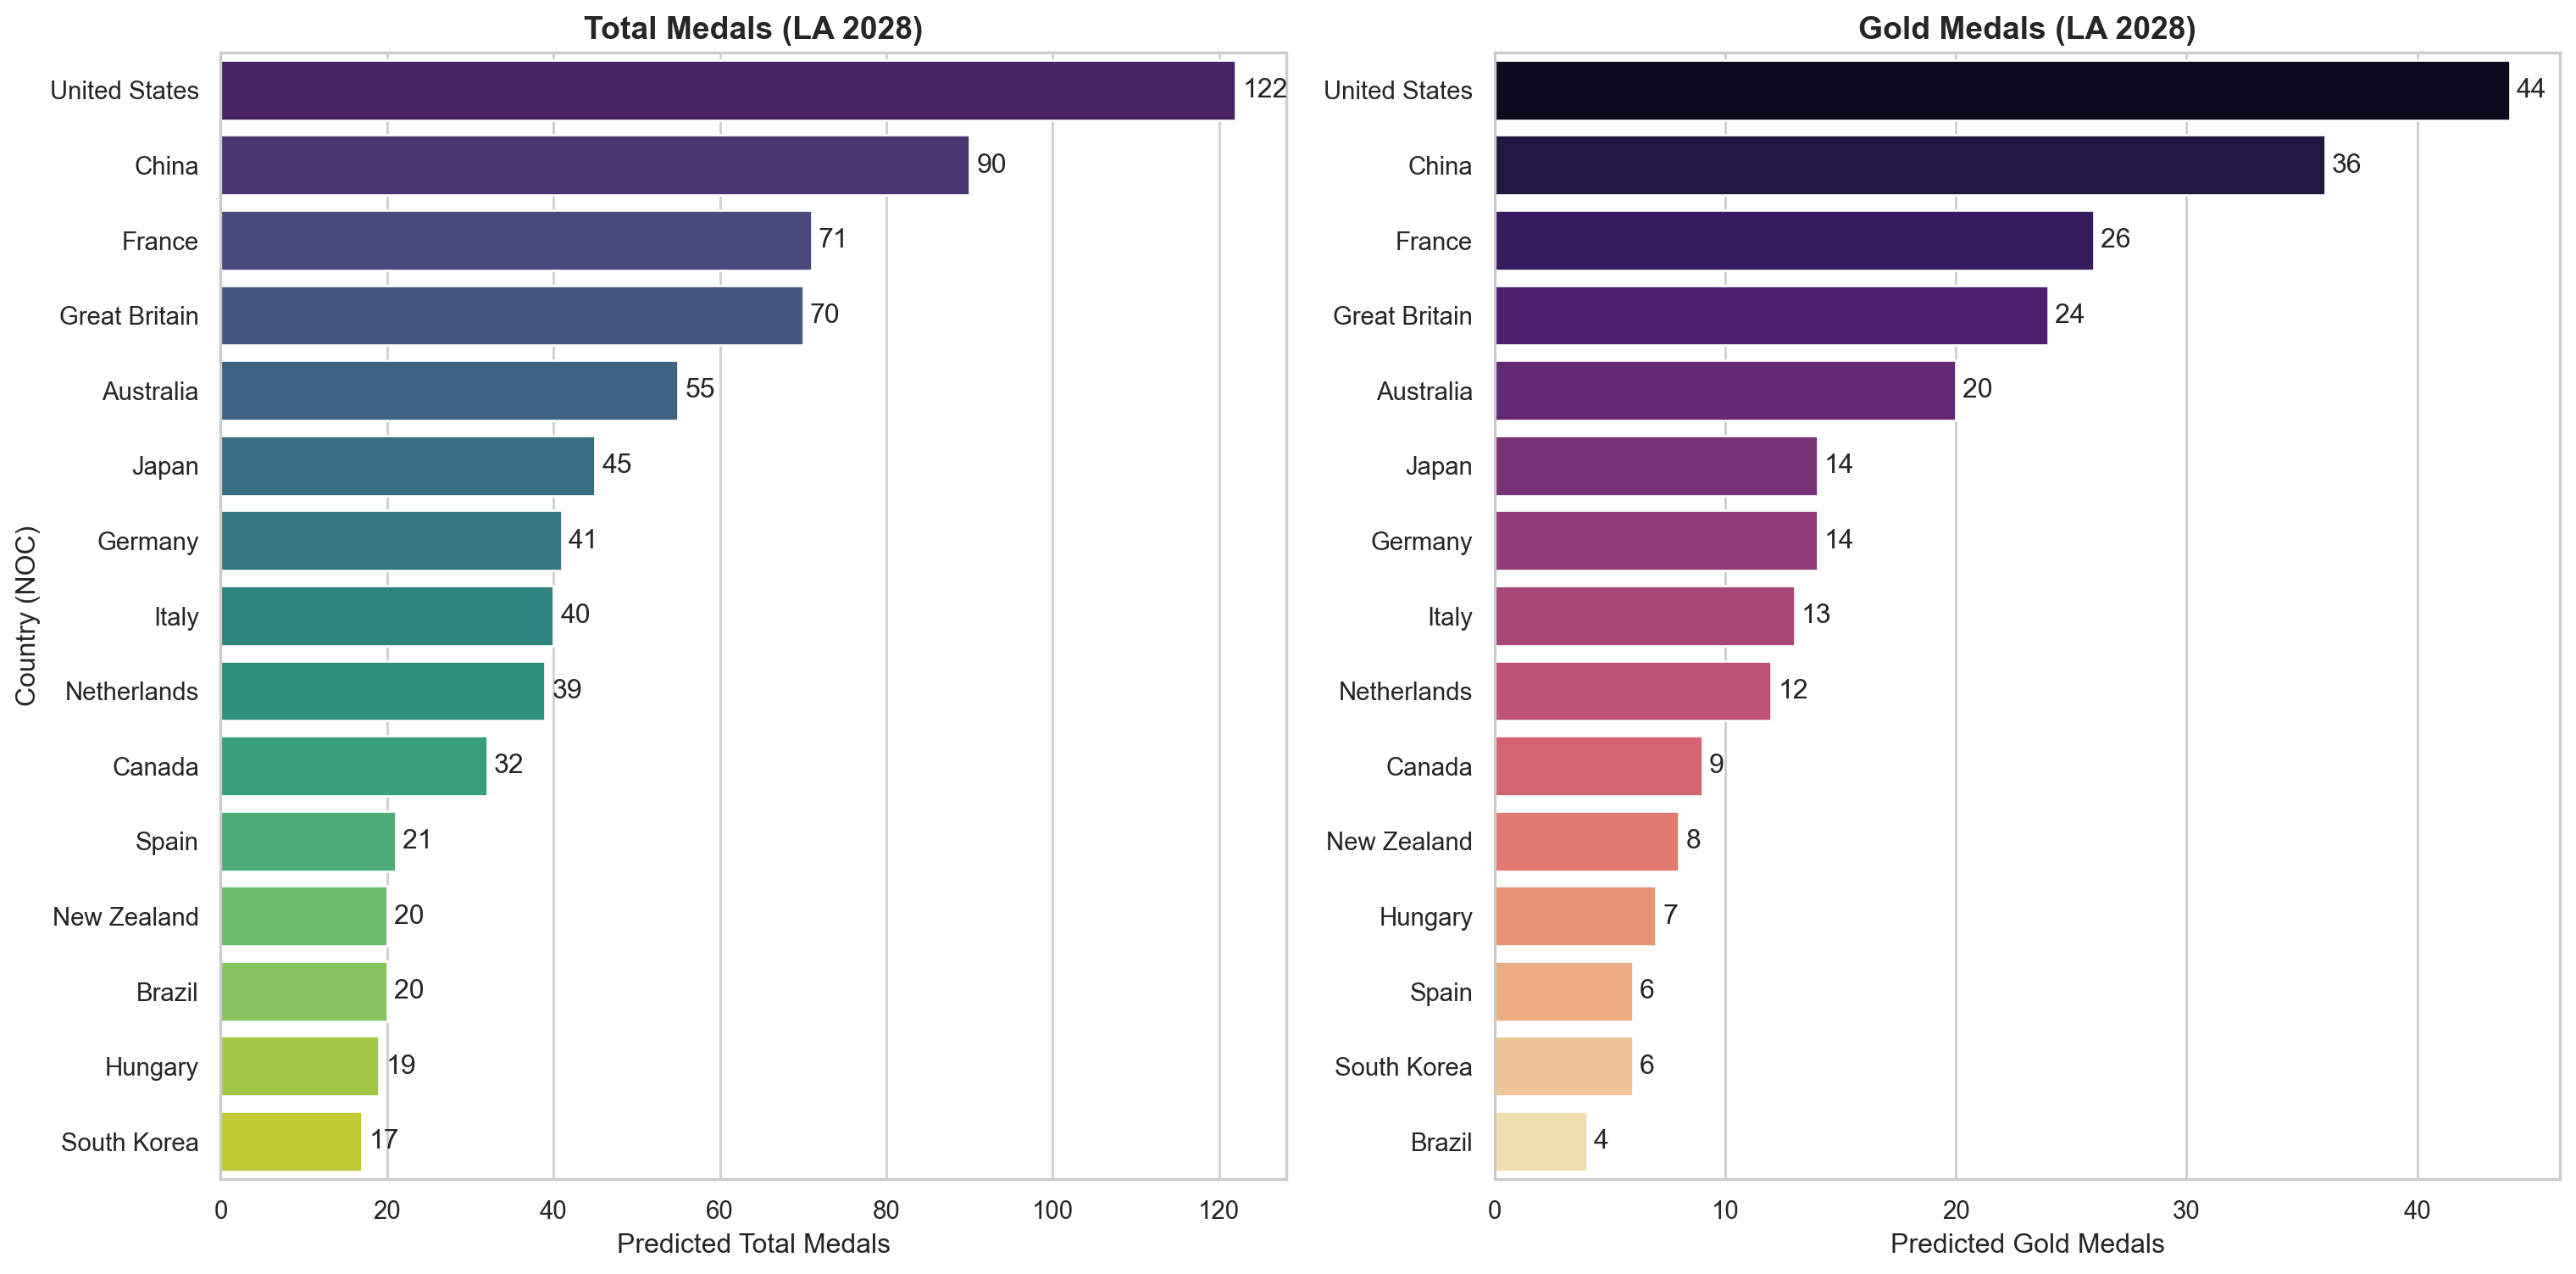

In [10]:
sns.set_theme(style="whitegrid")
plot_data = leaderboard_2028.head(15)

# Create a figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# --- CHART 1: TOTAL MEDALS (Left Side) ---
sns.barplot(
    x='Predicted_Total', 
    y='NOC', 
    data=plot_data.sort_values('Predicted_Total', ascending=False),
    palette='viridis',
    ax=ax1  # Tells seaborn to put this on the first subplot
)
ax1.set_title('Total Medals (LA 2028)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Predicted Total Medals')
ax1.set_ylabel('Country (NOC)')

# Add labels
for i in ax1.containers:
    ax1.bar_label(i, padding=3)

# --- CHART 2: GOLD MEDALS (Right Side) ---
sns.barplot(
    x='Predicted_Gold', 
    y='NOC', 
    data=plot_data.sort_values('Predicted_Gold', ascending=False),
    palette='magma',
    ax=ax2  # Tells seaborn to put this on the second subplot
)
ax2.set_title('Gold Medals (LA 2028)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Predicted Gold Medals')
ax2.set_ylabel('') # Remove Y-label on the second chart to save space

# Add labels
for i in ax2.containers:
    ax2.bar_label(i, padding=3)

# Adjust layout so they don't overlap
plt.tight_layout()
plt.show()

In [11]:
# 1. Base Framework: Athletes & Demographics per sport
# Pivot 'Sex' to get Male and Female counts per sport
sex_counts = athletes.groupby(['Year', 'Team', 'Sport', 'Sex']).size().unstack(fill_value=0).reset_index()

# Safety net: ensure columns exist even if data is weirdly shaped
if 'M' not in sex_counts.columns: sex_counts['M'] = 0
if 'F' not in sex_counts.columns: sex_counts['F'] = 0

sex_counts = sex_counts.rename(columns={'M': 'Male_Athletes', 'F': 'Female_Athletes'})
sex_counts['Sport_Athletes'] = sex_counts['Male_Athletes'] + sex_counts['Female_Athletes']

# Rename to match our pipeline
sport_athletes = sex_counts

# 2. Target Variables: Get all medal types simultaneously using .unstack()
valid_medals = athletes.dropna(subset=['Medal']).copy()
valid_medals = valid_medals[valid_medals['Medal'] != 'No medal']

# Group by Medal type and pivot
medal_breakdown = valid_medals.groupby(['Year', 'Team', 'Sport', 'Medal']).size().unstack(fill_value=0).reset_index()

# Ensure the columns exist
for col in ['Gold', 'Silver', 'Bronze']:
    if col not in medal_breakdown.columns:
        medal_breakdown[col] = 0

medal_breakdown = medal_breakdown.rename(columns={
    'Gold': 'Sport_Gold_Medals',
    'Silver': 'Sport_Silver_Medals',
    'Bronze': 'Sport_Bronze_Medals'
})

medal_breakdown['Sport_Total_Medals'] = (
    medal_breakdown['Sport_Gold_Medals'] + 
    medal_breakdown['Sport_Silver_Medals'] + 
    medal_breakdown['Sport_Bronze_Medals']
)

# 3. Merge into a single master table
df_sport = sport_athletes.merge(medal_breakdown, on=['Year', 'Team', 'Sport'], how='left')

# Fill NaNs with 0 (competed, but won 0 medals)
medal_cols = ['Sport_Total_Medals', 'Sport_Gold_Medals', 'Sport_Silver_Medals', 'Sport_Bronze_Medals']
df_sport[medal_cols] = df_sport[medal_cols].fillna(0)

# 4. Feature Engineering: The Lags & Efficiencies
# CRITICAL: We MUST sort by Team -> Sport -> Year
df_sport = df_sport.sort_values(by=['Team', 'Sport', 'Year'])

# Standard Lags
df_sport['Lag_1_Sport_Medals'] = df_sport.groupby(['Team', 'Sport'])['Sport_Total_Medals'].shift(1)
df_sport['Lag_2_Sport_Medals'] = df_sport.groupby(['Team', 'Sport'])['Sport_Total_Medals'].shift(2)

# Current Efficiency (Temporary, used to create the lag)
df_sport['Current_Sport_Efficiency'] = np.where(
    df_sport['Sport_Athletes'] > 0,
    df_sport['Sport_Total_Medals'] / df_sport['Sport_Athletes'],
    0
)
df_sport['Lag_1_Sport_Efficiency'] = df_sport.groupby(['Team', 'Sport'])['Current_Sport_Efficiency'].shift(1)
df_sport['Lag_2_Sport_Efficiency'] = df_sport.groupby(['Team', 'Sport'])['Current_Sport_Efficiency'].shift(2)


# NEW: Total Historical Efficiency
# Calculate cumulative sums, and shift them down 1 to prevent data leakage
cum_medals = df_sport.groupby(['Team', 'Sport'])['Sport_Total_Medals'].cumsum().shift(1)
cum_athletes = df_sport.groupby(['Team', 'Sport'])['Sport_Athletes'].cumsum().shift(1)

df_sport['Total_Historical_Efficiency'] = np.where(
    cum_athletes > 0,
    cum_medals / cum_athletes,
    0
)

# 5. Final Cleanup
cols_to_fill = [
    'Lag_1_Sport_Medals', 'Lag_2_Sport_Medals', 
    'Lag_1_Sport_Efficiency', 'Lag_2_Sport_Efficiency', 'Total_Historical_Efficiency'
]
df_sport[cols_to_fill] = df_sport[cols_to_fill].fillna(0)

# Drop the leaky variable
df_sport = df_sport.drop(columns=['Current_Sport_Efficiency'])

# 6. Bring in the Host Advantage
df_sport = df_sport.merge(hosts, on='Year', how='left')
df_sport['is_Host'] = df_sport.apply(lambda row: 1 if pd.notna(row['Host']) and str(row['Team']) in str(row['Host']) else 0, axis=1)
df_sport = df_sport.drop(columns=['Host'])

In [12]:
features = ['Sport', 'Team','Total_Historical_Efficiency', 'is_Host', 'Male_Athletes', 'Female_Athletes',  'Lag_1_Sport_Efficiency', 'Lag_2_Sport_Efficiency',  'Lag_1_Sport_Medals', 'Lag_2_Sport_Medals']
X = df_sport[features]

targets = ['Sport_Bronze_Medals', 'Sport_Silver_Medals', 'Sport_Gold_Medals', 'Sport_Total_Medals']
y = df_sport[targets]

X_train_sport, X_test_sport, y_train_multi_sport, y_test_multi_sport = train_test_split(X, y, train_size = .7, random_state = 4025)
num = [
    'Total_Historical_Efficiency', 
    'Male_Athletes', 
    'Female_Athletes', 
    'Lag_1_Sport_Efficiency', 
    'Lag_2_Sport_Efficiency', 
    'Lag_1_Sport_Medals', 
    'Lag_2_Sport_Medals'
]

cat = [
    'Sport', 
    'Team', 
    'is_Host'
]

In [13]:
num_transformer_impute = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_transformer_impute = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
])
preprocessor = ColumnTransformer([
    ('num', num_transformer_impute, num),
    ('cat', cat_transformer_impute, cat)
])

# Pipeline B: NO Imputer
num_transformer_no = Pipeline([
    ('scaler', StandardScaler())
])
cat_transformer_no = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessr_no_impute = ColumnTransformer([
    ('num', num_transformer_no, num),
    ('cat', cat_transformer_no, cat)
])
pipeline_impute = Pipeline([
    ('preprocessor', preprocessor), # Assumes preprocessor is defined above
    ('multi_regressor', MultiOutputRegressor(HistGradientBoostingRegressor(random_state=4025)))
])
pipeline_noimpute = Pipeline([
    ('preprocessor', preprocessr_no_impute),
    ('multi_regressor', MultiOutputRegressor(HistGradientBoostingRegressor(random_state=4025)))
])

models_to_test = {
    "HistGradient (WITH Imputer)": pipeline_impute,
    "HistGradient (NO Imputer)": pipeline_noimpute
}

param_grid = {
    'multi_regressor__estimator__learning_rate': [0.05, 0.1, 0.2],
    'multi_regressor__estimator__max_iter': [100, 200, 300],
    'multi_regressor__estimator__max_depth': [None, 5, 10]
}

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=4025)
results = {}

for name, pipeline in models_to_test.items():
    
    # Run GridSearch using NEW sport-level training data
    grid = GridSearchCV(pipeline, param_grid, cv=cv_strategy, scoring='r2', n_jobs=-1)
    grid.fit(X_train_sport, y_train_multi_sport)
    
    # Predict using NEW sport-level test data
    best_model = grid.best_estimator_
    preds = best_model.predict(X_test_sport)
    
    # Order of targets: [Bronze (0), Silver (1), Gold (2), Total (3)]
    
    # Calculate TOTAL Medals Metrics (Column 3)
    r2_tot = r2_score(y_test_multi_sport['Sport_Total_Medals'], preds[:, 3])
    rmse_tot = root_mean_squared_error(y_test_multi_sport['Sport_Total_Medals'], preds[:, 3])
    mae_tot = mean_absolute_error(y_test_multi_sport['Sport_Total_Medals'], preds[:, 3])

    # Calculate GOLD Medals Metrics (Column 2)
    r2_gld = r2_score(y_test_multi_sport['Sport_Gold_Medals'], preds[:, 2])
    rmse_gld = root_mean_squared_error(y_test_multi_sport['Sport_Gold_Medals'], preds[:, 2])
    mae_gld = mean_absolute_error(y_test_multi_sport['Sport_Gold_Medals'], preds[:, 2])

    # Calculate SILVER Medals Metrics (Column 1)
    r2_slv = r2_score(y_test_multi_sport['Sport_Silver_Medals'], preds[:, 1])
    rmse_slv = root_mean_squared_error(y_test_multi_sport['Sport_Silver_Medals'], preds[:, 1])
    mae_slv = mean_absolute_error(y_test_multi_sport['Sport_Silver_Medals'], preds[:, 1])

    # Calculate BRONZE Medals Metrics (Column 0)
    r2_brz = r2_score(y_test_multi_sport['Sport_Bronze_Medals'], preds[:, 0])
    rmse_brz = root_mean_squared_error(y_test_multi_sport['Sport_Bronze_Medals'], preds[:, 0])
    mae_brz = mean_absolute_error(y_test_multi_sport['Sport_Bronze_Medals'], preds[:, 0])
    
    # Save ALL results
    results[name] = {
        'Total_R2': r2_tot, 'Total_RMSE': rmse_tot, 'Total_MAE': mae_tot,
        'Gold_R2': r2_gld,  'Gold_RMSE': rmse_gld,  'Gold_MAE': mae_gld,
        'Silver_R2': r2_slv,'Silver_RMSE': rmse_slv,'Silver_MAE': mae_slv,
        'Bronze_R2': r2_brz,'Bronze_RMSE': rmse_brz,'Bronze_MAE': mae_brz,
        'BestParams': grid.best_params_
    }

In [14]:
# 1. Isolate the 2024 sport-level data to act as our launch pad
data_2024 = df_sport[df_sport['Year'] == 2024].copy()

# Create the base 2028 DataFrame
data_2028 = pd.DataFrame()
data_2028['Team'] = data_2024['Team'].values
data_2028['Sport'] = data_2024['Sport'].values
data_2028['Year'] = 2028

# 2. Assign Host Advantage (Checking if the Team name is the United States)
data_2028['is_Host'] = data_2028['Team'].apply(lambda x: 1 if 'United States' in str(x) else 0)

# 3. Carry over Demographic Data (Using 2024 as the proxy for 2028)
data_2028['Male_Athletes'] = data_2024['Male_Athletes'].values
data_2028['Female_Athletes'] = data_2024['Female_Athletes'].values
data_2028['Sport_Athletes'] = data_2028['Male_Athletes'] + data_2028['Female_Athletes']

# 4. Shift the Sport-Specific Lags Forward
# 2028's Lag 1 is the ACTUAL medals won in that specific sport in 2024
data_2028['Lag_1_Sport_Medals'] = data_2024['Sport_Total_Medals'].values
# 2028's Lag 2 is 2024's Lag 1
data_2028['Lag_2_Sport_Medals'] = data_2024['Lag_1_Sport_Medals'].values

safe_athletes = data_2024['Sport_Athletes'].replace(0, np.nan)
actual_2024_efficiency = (data_2024['Sport_Total_Medals'] / safe_athletes).fillna(0)

# Assign it cleanly as a numpy array
data_2028['Lag_1_Efficiency'] = actual_2024_efficiency.values

# THE FIX 2: Safely pull Lag 2 depending on exactly what your historical dataframe named it.
if 'Lag_1_Efficiency' in data_2024.columns:
    data_2028['Lag_2_Efficiency'] = data_2024['Lag_1_Efficiency'].values
elif 'Lag_1_Sport_Efficiency' in data_2024.columns:
    data_2028['Lag_2_Efficiency'] = data_2024['Lag_1_Sport_Efficiency'].values
else:
    # Absolute safety fallback to prevent a crash
    data_2028['Lag_2_Efficiency'] = 0

# Carry over the cumulative historical efficiency
data_2028['Total_Historical_Efficiency'] = data_2024['Total_Historical_Efficiency'].values

# 6. Ensure features match EXACTLY what the model was trained on
# Instead of guessing the names, we pull the exact list directly from your training data
features = X_train_sport.columns.tolist()

# Safety net: If the 2028 data is missing a specific lag column that the model expects, 
# this loop will create it and safely fill it with 0 so the model doesn't crash.
for col in features:
    if col not in data_2028.columns:
          data_2028[col] = 0

# Now we isolate the 2028 data using that exact, perfect list
X_2028 = data_2028[features]


# 7. Predict using your winning model! 
predictions_2028 = best_model.predict(X_2028)


# 8. Extract Predictions using the target index order: [Bronze (0), Silver (1), Gold (2), Total (3)]
data_2028['Predicted_Bronze'] = np.round(predictions_2028[:, 0]).clip(min=0).astype(int)
data_2028['Predicted_Silver'] = np.round(predictions_2028[:, 1]).clip(min=0).astype(int)
data_2028['Predicted_Gold'] = np.round(predictions_2028[:, 2]).clip(min=0).astype(int)
data_2028['Predicted_Total'] = np.round(predictions_2028[:, 3]).clip(min=0).astype(int)


# ==========================================
# VIEW 1: THE MOST DOMINANT SPORT EVENTS
# ==========================================
top_events = data_2028.sort_values(by=['Predicted_Gold', 'Predicted_Total'], ascending=[False, False])

C:\Users\cjfoo\AppData\Local\Temp\ipykernel_9408\2932306214.py:33: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
C:\Users\cjfoo\miniforge3\envs\math4025\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.


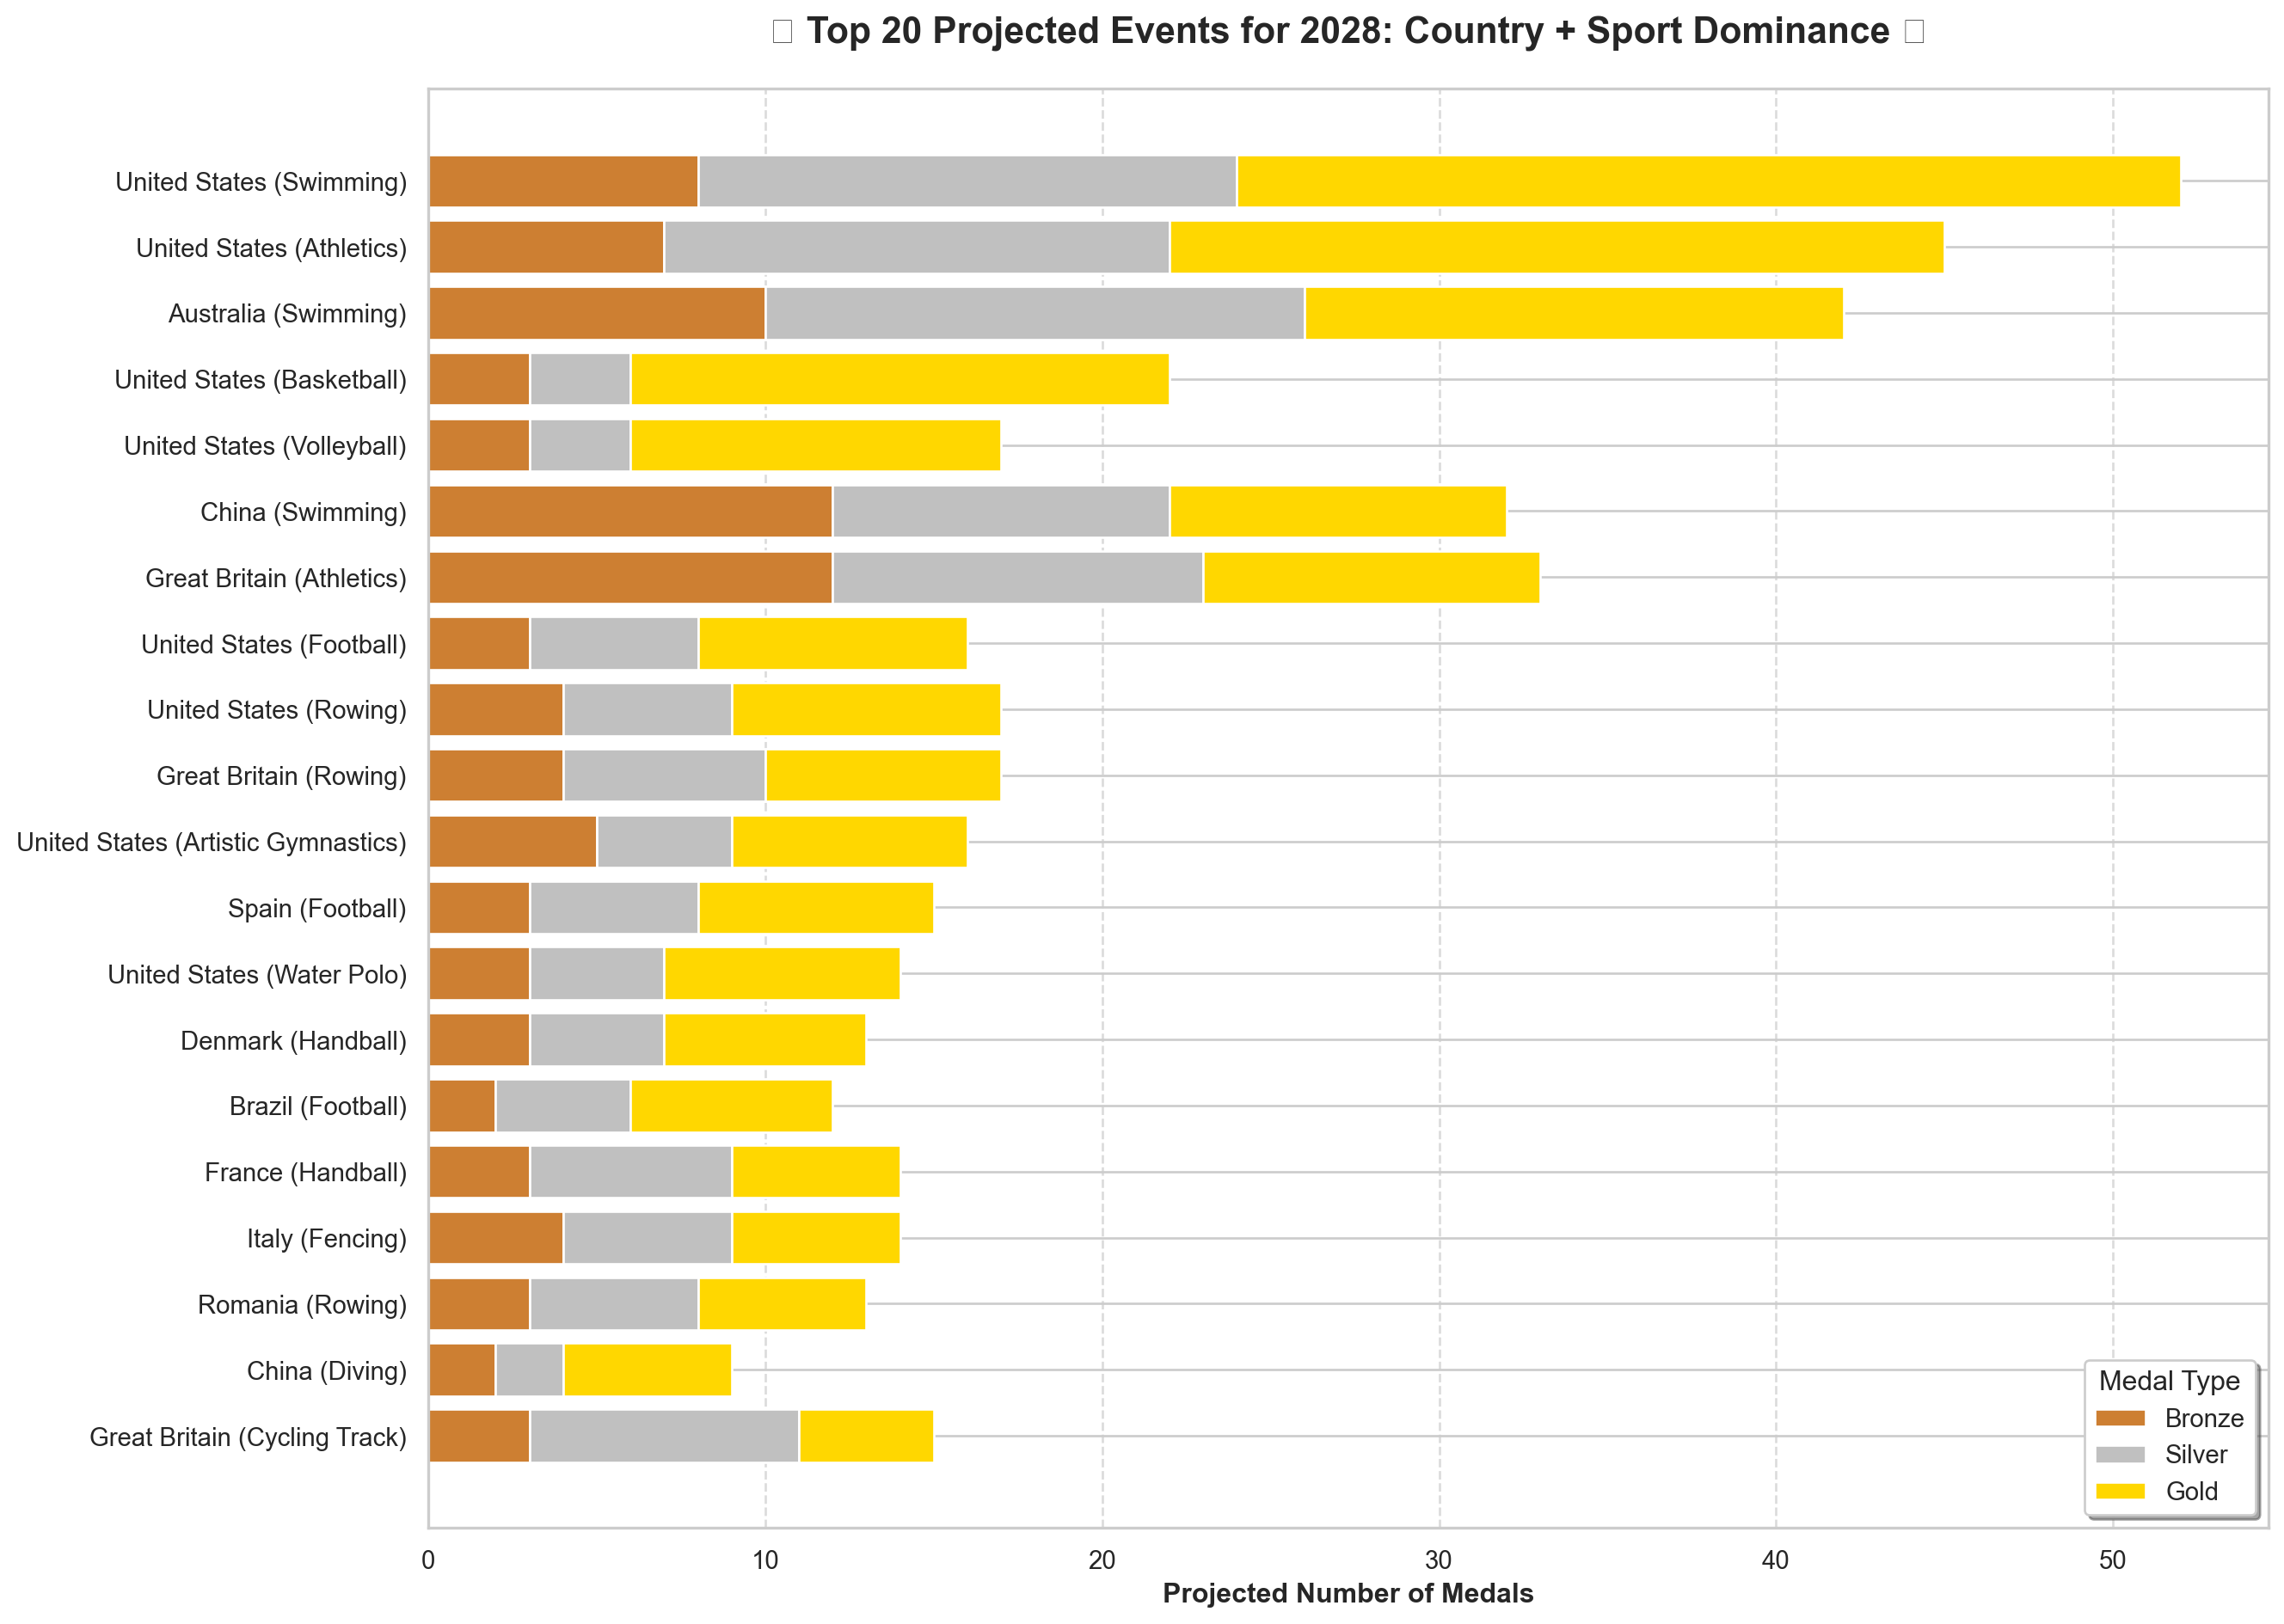

In [15]:
# 1. Prepare the Top 20 data
# We use the top_events dataframe we created in the previous step
top_20_events = top_events.head(20).copy()

# Create a clean label combining Team and Sport
top_20_events['Label'] = top_20_events['Team'] + " (" + top_20_events['Sport'] + ")"

# 2. Set up the plotting arrays
labels = top_20_events['Label'].values
gold = top_20_events['Predicted_Gold'].values
silver = top_20_events['Predicted_Silver'].values
bronze = top_20_events['Predicted_Bronze'].values
y_pos = np.arange(len(labels))

# 3. Create the stacked bar chart
plt.figure(figsize=(14, 10))

# Plot Bronze first, then stack Silver on top, then Gold on top of that
plt.barh(y_pos, bronze, color='#CD7F32', label='Bronze', edgecolor='white')
plt.barh(y_pos, silver, left=bronze, color='#C0C0C0', label='Silver', edgecolor='white')
plt.barh(y_pos, gold, left=bronze + silver, color='#FFD700', label='Gold', edgecolor='white')

# 4. Add styling and labels
plt.yticks(y_pos, labels, fontsize=11)
plt.gca().invert_yaxis()  # Highest gold count at the top
plt.xlabel('Projected Number of Medals', fontsize=12, fontweight='bold')
plt.title('🔥 Top 20 Projected Events for 2028: Country + Sport Dominance 🔥', fontsize=16, fontweight='bold', pad=20)
plt.legend(title="Medal Type", loc='lower right', frameon=True, shadow=True)

# Add gridlines for the X-axis to make it easier to read counts
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

C:\Users\cjfoo\AppData\Local\Temp\ipykernel_9408\4042297357.py:35: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
C:\Users\cjfoo\miniforge3\envs\math4025\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.


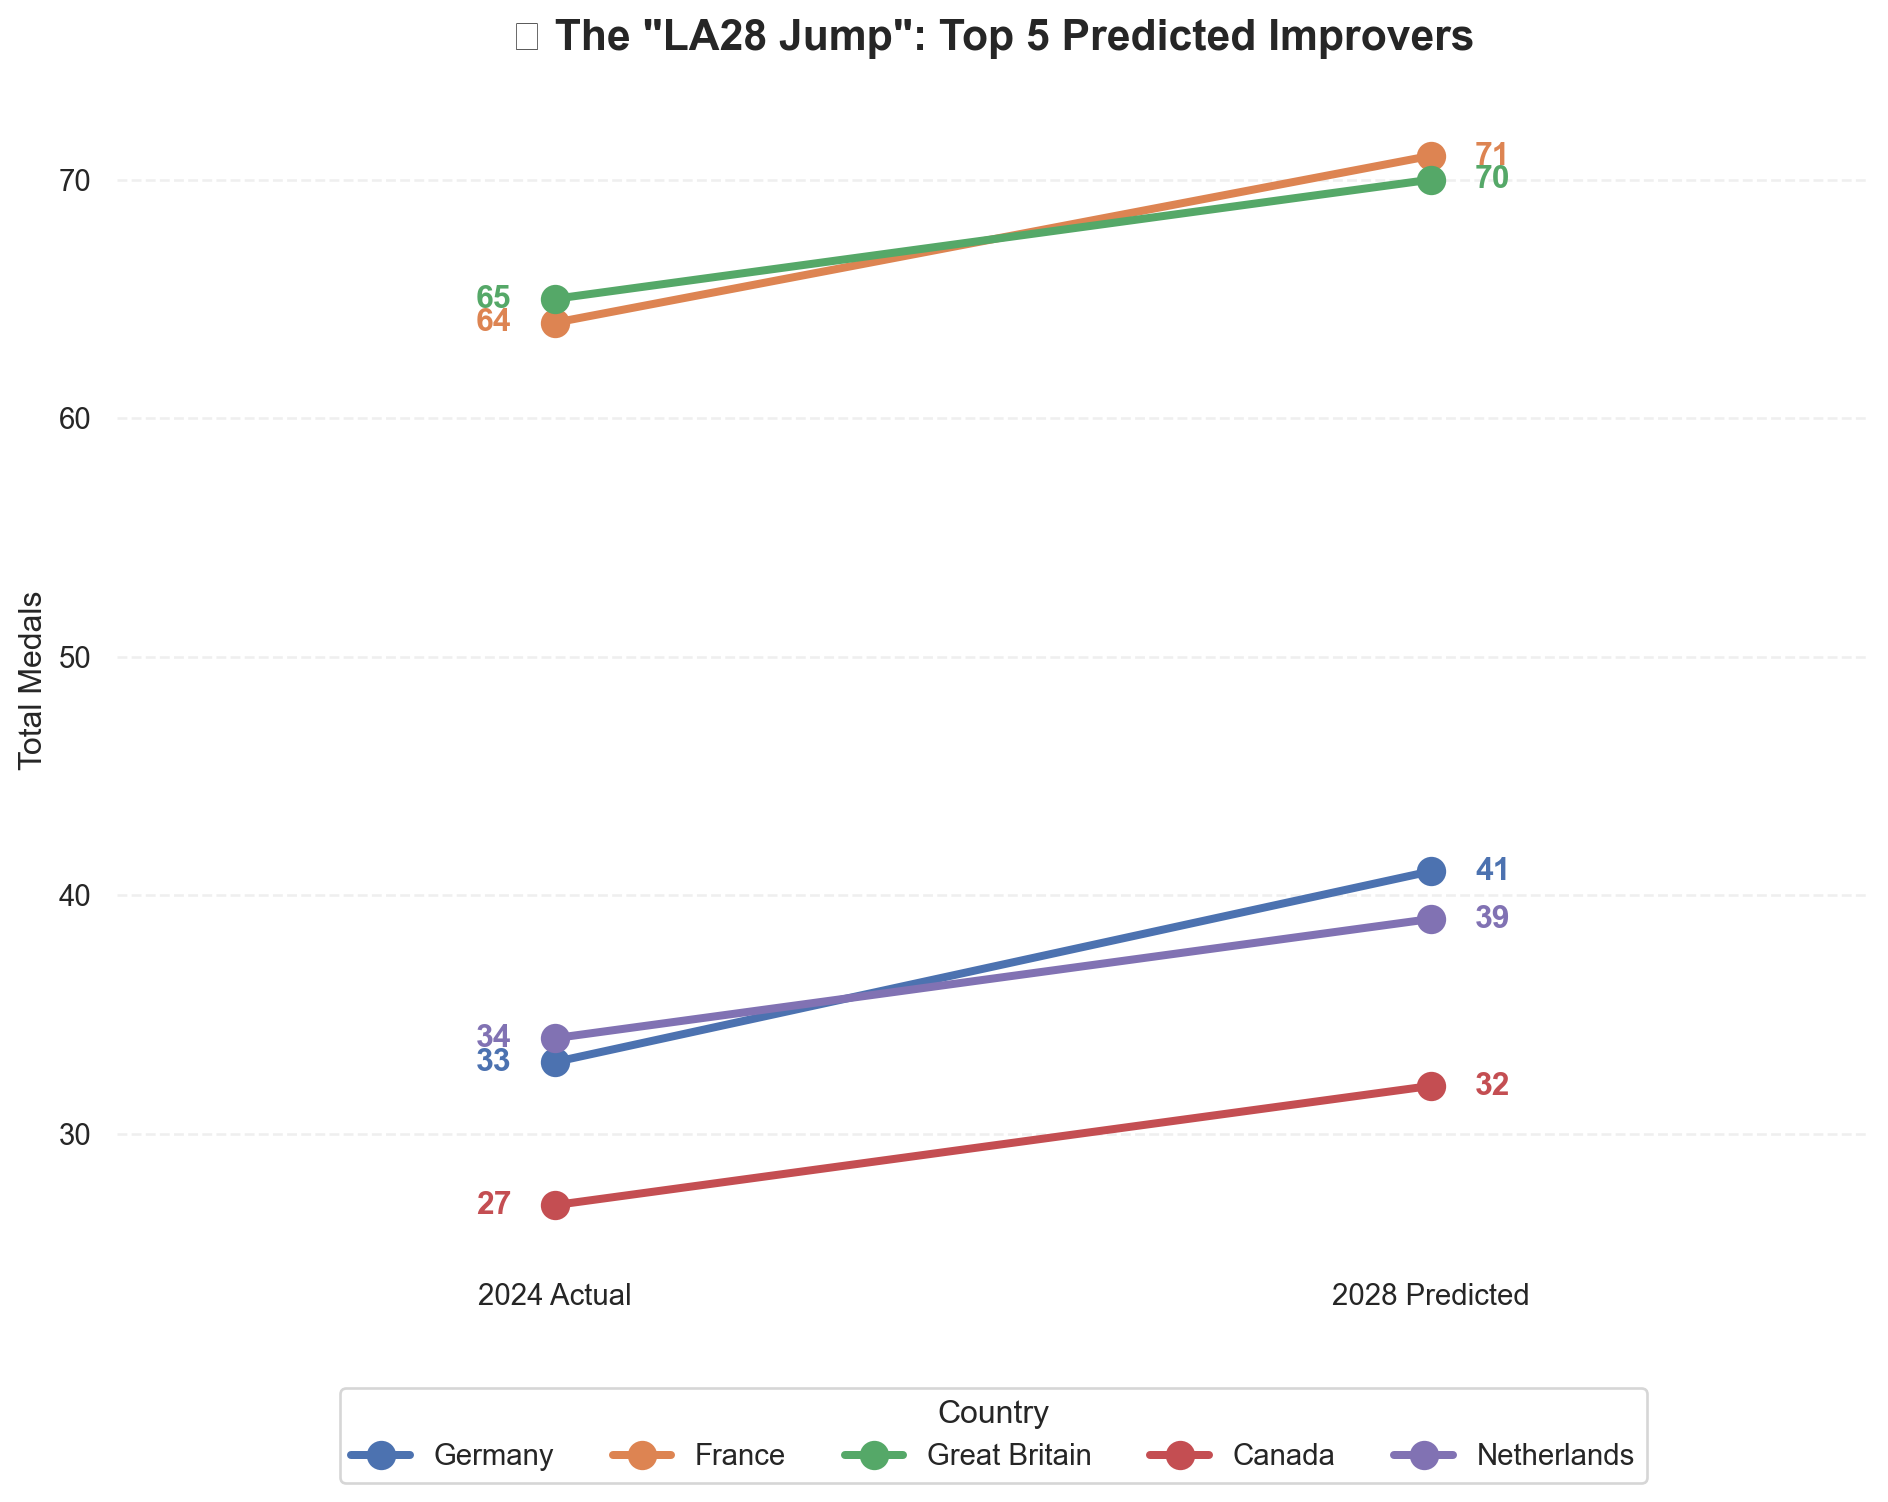

In [16]:
# 1. Calculate the 'Improvement' so we can find the biggest jumpers
# In your model, 'Lag_1_Total_Medals' is the actual 2024 count
leaderboard_2028['Improvement'] = leaderboard_2028['Predicted_Total'] - leaderboard_2028['Lag_1_Total_Medals']

# 2. Get the Top 5 countries that the model thinks will improve the most
top_improvers = leaderboard_2028.sort_values(by='Improvement', ascending=False).head(5)

# 3. Create the Slope Chart
plt.figure(figsize=(10, 8))
sns.set_style("white")

for i, row in top_improvers.iterrows():
    # x-axis points
    x_labels = ['2024 Actual', '2028 Predicted']
    # y-axis points (2024 actual vs 2028 predicted)
    y_values = [row['Lag_1_Total_Medals'], row['Predicted_Total']]
    
    # Plot the line for this country
    line = plt.plot(x_labels, y_values, marker='o', linewidth=3, markersize=10, label=row['NOC'])
    
    # Add text labels for the specific medal counts next to the points
    plt.text(-0.05, row['Lag_1_Total_Medals'], f"{int(row['Lag_1_Total_Medals'])}", 
             ha='right', va='center', fontweight='bold', color=line[0].get_color())
    plt.text(1.05, row['Predicted_Total'], f"{int(row['Predicted_Total'])}", 
             ha='left', va='center', fontweight='bold', color=line[0].get_color())

# 4. Polish the chart
plt.title('📈 The "LA28 Jump": Top 5 Predicted Improvers', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Total Medals', fontsize=12)
plt.xlim(-0.5, 1.5)  # Add breathing room for the text labels
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(title="Country", loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()